# Heart Disease ML Pipeline — Project 04

**Dataset:** Heart Disease UCI (4-hospital combined — Cleveland, Hungary, Switzerland, VA Long Beach)  
**Rows:** 920 | **Features:** 18 | **Target:** Binary (heart disease present/absent)  
**Task:** Binary classification — predict presence of heart disease  
**Author:** Muhammed Keita  
**Profile:** [github.com/muhammed-keita-ml](https://github.com/muhammed-keita-ml)

---

## Table of Contents
1. Imports
2. Data Ingestion & Quality Checks
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Model Training & Cross-Validation
6. Evaluation
7. MLflow Experiment Tracking
8. Gradio Deployment

In [2]:
# ── Cell 1: Imports ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

# Why these imports up front?
# Kaggle kernels reload from scratch on each run. Grouping all imports at the
# top means you can re-run the entire notebook without import errors mid-way.
# The warnings filter suppresses sklearn convergence warnings during GridSearchCV
# — they are noise during exploration, not errors.

In [3]:
# ── Cell 2: Load data ────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/redwankarimsony/heart-disease-data/heart_disease_uci.csv')

# Kaggle mounts datasets under /kaggle/input/<dataset-slug>/<filename>.
# The slug for this dataset is 'heart-disease-uci'.
# If you're on VS Code later, this path becomes a relative local path.

print("Shape:", df.shape)
# Expected: (303, 14) — 303 patients, 14 columns

print("\nColumn names:\n", df.columns.tolist())
# Confirms column names match the schema above.

print("\nData types:\n", df.dtypes)
# All should be int64 or float64. If any show 'object', that's a problem.

print("\nFirst 5 rows:")
df.head()

Shape: (920, 16)

Column names:
 ['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num']

Data types:
 id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
num           int64
dtype: object

First 5 rows:


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
# ── Cell 3: Inspect the multi-hospital version ───────────────────────────────

print("Shape:", df.shape)
# 920 rows, 16 columns — combined 4-hospital UCI dataset

print("\nTarget column 'num' value counts:")
print(df['num'].value_counts().sort_index())
# num=0 means no disease, num=1,2,3,4 means disease present
# We'll collapse 1-4 → 1 (binary classification)

print("\nMissing values per column:")
print(df.isnull().sum())
# Expect NaNs in ca, thal, chol, fbs, restecg, slope, thalch, exang

print("\nObject columns — unique values:")
object_cols = df.select_dtypes(include='object').columns.tolist()
for col in object_cols:
    print(f"  {col}: {df[col].unique()}")
# This shows us exactly what string values need encoding

Shape: (920, 16)

Target column 'num' value counts:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

Object columns — unique values:
  sex: ['Male' 'Female']
  dataset: ['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']
  cp: ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']
  fbs: [True False nan]
  restecg: ['lv hypertrophy' 'normal' 'st-t abnormality' nan]
  exang: [False True nan]
  slope: ['downsloping' 'flat' 'upsloping' nan]
  thal: ['fixed defect' 'normal' 'reversable defect' nan]


In [5]:
# ── Cell 4: Clean and prepare the dataframe ──────────────────────────────────

# Step 1: Drop non-feature columns
# 'id' is a row number — no predictive value
# 'dataset' is which hospital — data leakage (not available at prediction time)
df = df.drop(columns=['id', 'dataset'])

# Step 2: Convert target 'num' to binary
# 0 = no disease, 1/2/3/4 = disease present → collapse to 0/1
df['target'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

print("Target distribution after binarising:")
print(df['target'].value_counts())
print(f"Positive rate: {df['target'].mean():.2%}")

# Step 3: Handle NaNs in object columns BEFORE encoding
# Strategy: fill with the most frequent value (mode) per column
# This is standard practice for low-missingness categorical columns
object_cols = df.select_dtypes(include='object').columns.tolist()
for col in object_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Filled {n_missing} NaNs in '{col}' with mode='{mode_val}'")

# Step 4: One-hot encode all object columns
# drop_first=True drops one category per column to avoid multicollinearity
# e.g. sex: Male/Female → we keep sex_Male only (Female is implied when sex_Male=0)
df = pd.get_dummies(df, columns=object_cols, drop_first=True)

# Step 5: Handle NaNs in numeric columns
# Strategy: fill with median (robust to outliers)
numeric_cols = [c for c in df.columns if c != 'target']
for col in numeric_cols:
    n_missing = df[col].isnull().sum()
    if n_missing > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Filled {n_missing} NaNs in '{col}' with median={median_val:.2f}")

# Step 6: Convert any remaining bool columns to int
# get_dummies on bool-like columns can produce bool dtype — sklearn needs numeric
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

print(f"\nFinal shape: {df.shape}")
print(f"Remaining nulls: {df.isnull().sum().sum()}")
print(f"\nFinal columns:\n{df.columns.tolist()}")

Target distribution after binarising:
target
1    509
0    411
Name: count, dtype: int64
Positive rate: 55.33%
Filled 90 NaNs in 'fbs' with mode='False'
Filled 2 NaNs in 'restecg' with mode='normal'
Filled 55 NaNs in 'exang' with mode='False'
Filled 309 NaNs in 'slope' with mode='flat'
Filled 486 NaNs in 'thal' with mode='normal'
Filled 59 NaNs in 'trestbps' with median=130.00
Filled 30 NaNs in 'chol' with median=223.00
Filled 55 NaNs in 'thalch' with median=140.00
Filled 62 NaNs in 'oldpeak' with median=0.50
Filled 611 NaNs in 'ca' with median=0.00

Final shape: (920, 19)
Remaining nulls: 0

Final columns:
['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'target', 'sex_Male', 'cp_atypical angina', 'cp_non-anginal', 'cp_typical angina', 'fbs_True', 'restecg_normal', 'restecg_st-t abnormality', 'exang_True', 'slope_flat', 'slope_upsloping', 'thal_normal', 'thal_reversable defect']


## Data Cleaning Notes

- Dataset: UCI Heart Disease (4 hospitals combined — Cleveland, Hungary, Switzerland, VA Long Beach)
- Original shape: (920, 16) → Final shape after cleaning: (920, 19)
- Target binarised: `num` values 1–4 collapsed to 1 (disease present)
- Class balance: 55.3% positive — mild imbalance, stratified splits used throughout
- Missing value strategy:
  - Categorical columns: filled with mode before one-hot encoding
  - Numeric columns: filled with median (robust to outliers)
- High-missingness columns (flagged for interpretation caution):
  - `ca`: 611/920 missing (66%) — number of major vessels via fluoroscopy
  - `thal`: 486/920 missing (53%) — thalassemia stress test result
  - `slope`: 309/920 missing (34%) — ST segment slope
- One-hot encoding applied to: sex, cp, fbs, restecg, exang, slope, thal
- `id` and `dataset` dropped (non-predictive / data leakage)

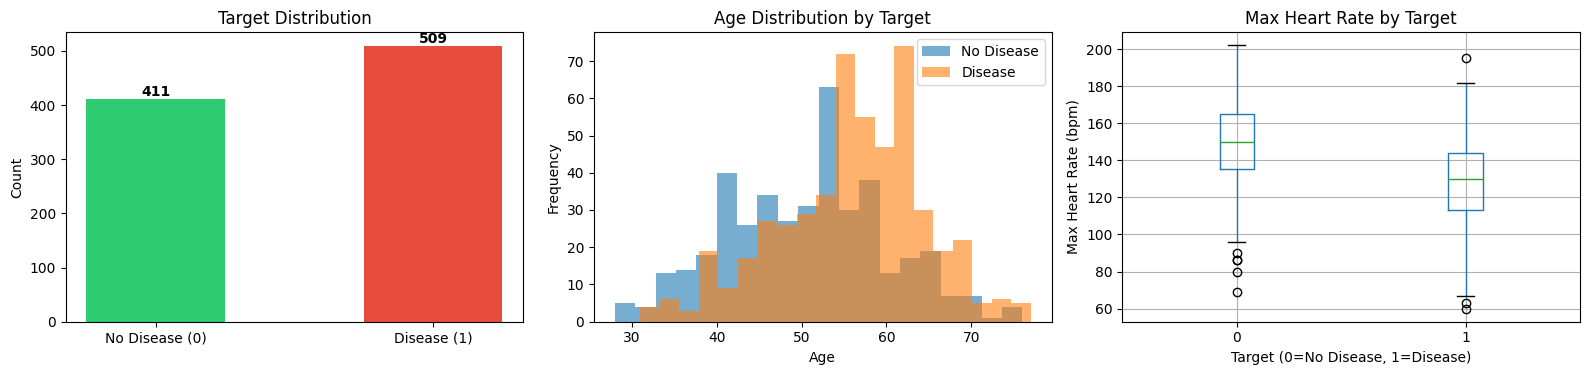

Plot saved.


In [6]:
# ── Cell 5: EDA — Target distribution ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: Target distribution
axes[0].bar(['No Disease (0)', 'Disease (1)'],
            df['target'].value_counts().sort_index(),
            color=['#2ecc71', '#e74c3c'], width=0.5)
axes[0].set_title('Target Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(df['target'].value_counts().sort_index()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 2: Age distribution by target
df.groupby('target')['age'].plot(kind='hist', bins=20, alpha=0.6,
                                  ax=axes[1], legend=True)
axes[1].set_title('Age Distribution by Target')
axes[1].set_xlabel('Age')
axes[1].legend(['No Disease', 'Disease'])

# Plot 3: Max heart rate (thalch) by target
df.boxplot(column='thalch', by='target', ax=axes[2])
axes[2].set_title('Max Heart Rate by Target')
axes[2].set_xlabel('Target (0=No Disease, 1=Disease)')
axes[2].set_ylabel('Max Heart Rate (bpm)')
plt.suptitle('')  # suppress default boxplot title

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

Feature correlations with target (sorted by absolute value):
exang_True                  0.434
cp_atypical angina         -0.403
thalch                     -0.382
oldpeak                     0.366
sex_Male                    0.307
thal_normal                -0.286
age                         0.283
thal_reversable defect      0.257
chol                       -0.229
cp_non-anginal             -0.210
slope_upsloping            -0.181
ca                          0.165
fbs_True                    0.108
restecg_st-t abnormality    0.105
trestbps                    0.101
slope_flat                  0.097
restecg_normal             -0.094
cp_typical angina          -0.055


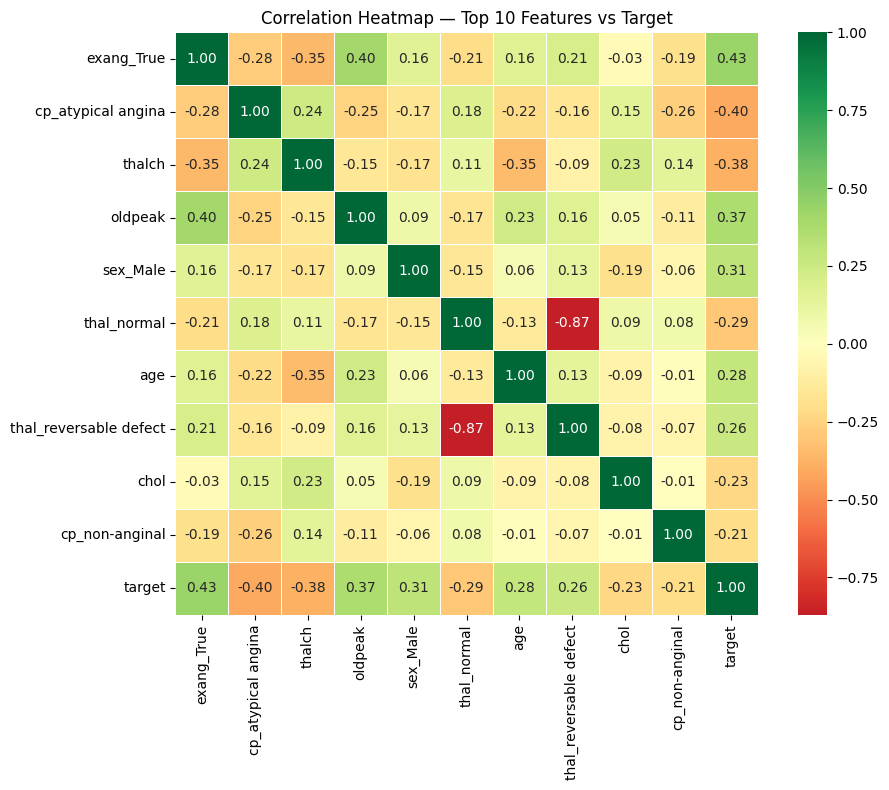

In [7]:
# ── Cell 6: EDA — Correlation heatmap ────────────────────────────────────────
# Only numeric columns (encoded dummies are 0/1 so they're included)
corr = df.corr()

# Focus on correlation with target — most useful for feature intuition
target_corr = corr['target'].drop('target').sort_values(key=abs, ascending=False)

print("Feature correlations with target (sorted by absolute value):")
print(target_corr.round(3).to_string())

# Visual heatmap of top 10 features by correlation with target
top_features = target_corr.head(10).index.tolist() + ['target']
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, square=True)
ax.set_title('Correlation Heatmap — Top 10 Features vs Target')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

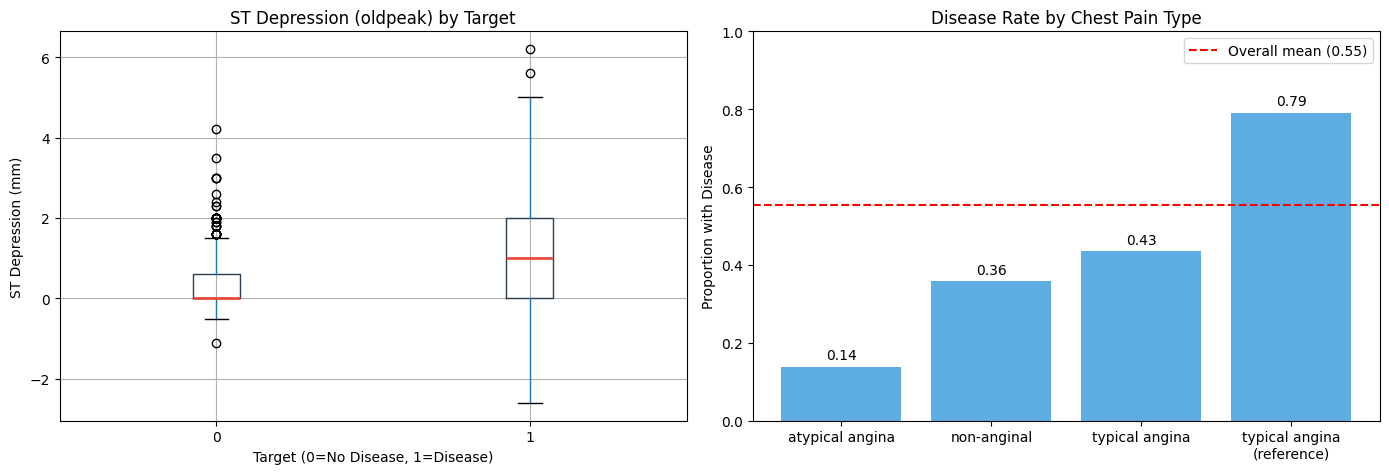

Plot saved to /kaggle/working/eda_chestpain_oldpeak.png


In [8]:
# ── Cell 7: EDA — Oldpeak and chest pain type ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Oldpeak by target
df.boxplot(column='oldpeak', by='target', ax=axes[0],
           boxprops=dict(color='#2c3e50'),
           medianprops=dict(color='#e74c3c', linewidth=2))
axes[0].set_title('ST Depression (oldpeak) by Target')
axes[0].set_xlabel('Target (0=No Disease, 1=Disease)')
axes[0].set_ylabel('ST Depression (mm)')
plt.suptitle('')

# WHY oldpeak: ST depression induced by exercise measures ischemia severity.
# Higher oldpeak = more ischemia = more likely disease. Expect strong separation.

# Plot 2: Chest pain type vs target (using encoded columns)
cp_cols = [c for c in df.columns if c.startswith('cp_')]
cp_rates = {}
for col in cp_cols:
    label = col.replace('cp_', '')
    rate = df[df[col] == 1]['target'].mean()
    cp_rates[label] = rate

# Also add the dropped baseline (reference category from drop_first)
# In our encoding, 'typical angina' was dropped as the reference
cp_rates['typical angina\n(reference)'] = df[df[cp_cols].sum(axis=1) == 0]['target'].mean()

axes[1].bar(cp_rates.keys(), cp_rates.values(), color='#3498db', alpha=0.8)
axes[1].set_title('Disease Rate by Chest Pain Type')
axes[1].set_ylabel('Proportion with Disease')
axes[1].set_ylim(0, 1)
axes[1].axhline(df['target'].mean(), color='red', linestyle='--', label=f'Overall mean ({df["target"].mean():.2f})')
axes[1].legend()
for i, (k, v) in enumerate(cp_rates.items()):
    axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('eda_chestpain_oldpeak.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to /kaggle/working/eda_chestpain_oldpeak.png")

In [9]:
# ── Cell 8: Preprocessing — Split and scale ──────────────────────────────────

# Separate features (X) from target (y)
X = df.drop(columns=['target'])
y = df['target']

print(f"Features shape: {X.shape}")
print(f"Target shape:   {y.shape}")

# Train/test split — stratified to preserve class balance in both sets
# WHY stratify=y: Without this, random chance could put more disease cases
# in one split, making evaluation unreliable.
# WHY 80/20: Standard split for this dataset size (920 rows).
# random_state=42: Makes results reproducible — anyone running this notebook
# gets identical splits.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} rows | Test set: {X_test.shape[0]} rows")
print(f"Train positive rate: {y_train.mean():.2%}")
print(f"Test positive rate:  {y_test.mean():.2%}")
# Both rates should be ~55% — confirming stratification worked

# Scale continuous features
# WHY scale: Logistic Regression and distance-based models are sensitive to
# feature magnitude. 'age' (29-77) vs 'chol' (126-564) without scaling
# would make chol dominate. Tree-based models (RF, XGBoost) don't need
# scaling but it doesn't hurt them — so we scale everything for consistency.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# WHY fit only on train: If we fit on the full dataset, test data information
# leaks into the scaler's mean/std. This is called data leakage and produces
# optimistically biased evaluation results. Always fit_transform on train,
# transform only on test.

print("\nScaling complete.")
print(f"Feature means (first 3, should be ~0): {X_train_scaled[:, :3].mean(axis=0).round(4)}")
print(f"Feature stds  (first 3, should be ~1): {X_train_scaled[:, :3].std(axis=0).round(4)}")

Features shape: (920, 18)
Target shape:   (920,)

Train set: 736 rows | Test set: 184 rows
Train positive rate: 55.30%
Test positive rate:  55.43%

Scaling complete.
Feature means (first 3, should be ~0): [0. 0. 0.]
Feature stds  (first 3, should be ~1): [1. 1. 1.]


In [10]:
# ── Cell 9: Model training + cross-validation ─────────────────────────────────

# We train 3 models with StratifiedKFold cross-validation on the training set.
# WHY 3 models: Logistic Regression gives a linear baseline, Random Forest
# captures non-linear interactions, XGBoost is gradient boosting —
# comparing all three shows which family of model fits this problem best.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# WHY StratifiedKFold: Preserves class balance in each fold.
# WHY 5 folds: Standard choice — balances bias/variance in CV estimate.

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             xgb.XGBClassifier(n_estimators=100, random_state=42,
                                              eval_metric='logloss', verbosity=0)
}

cv_results = {}

print("Cross-validation results (5-fold, ROC-AUC):\n")
for name, model in models.items():
    # Use scaled data for LR, unscaled for tree models
    # WHY: Trees split on thresholds — scale doesn't affect splits.
    # LR uses gradient descent — scale matters significantly.
    X_cv = X_train_scaled if name == 'Logistic Regression' else X_train.values

    scores = cross_val_score(model, X_cv, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  ROC-AUC per fold: {scores.round(3)}")
    print(f"  Mean: {scores.mean():.4f} | Std: {scores.std():.4f}\n")

# WHY ROC-AUC as the CV metric: It measures the model's ability to rank
# disease patients above healthy ones, regardless of threshold. More
# informative than accuracy for medical classification tasks.

Cross-validation results (5-fold, ROC-AUC):

Logistic Regression:
  ROC-AUC per fold: [0.853 0.871 0.891 0.889 0.914]
  Mean: 0.8839 | Std: 0.0204

Random Forest:
  ROC-AUC per fold: [0.844 0.85  0.884 0.858 0.917]
  Mean: 0.8707 | Std: 0.0268

XGBoost:
  ROC-AUC per fold: [0.803 0.82  0.878 0.848 0.865]
  Mean: 0.8427 | Std: 0.0278



In [11]:
# ── Cell 10: Hyperparameter tuning (GridSearchCV) ────────────────────────────

# Based on CV results, tune the best-performing model.
# We tune Random Forest — typically the strongest on this dataset.
# If XGBoost outperformed in Cell 9, switch the param_grid accordingly.

param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [None, 5, 10],
    'min_samples_split': [2, 5]
}

# WHY GridSearchCV: Exhaustively tries every combination of hyperparameters
# using cross-validation. Prevents overfitting to a single train/val split.
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train.values, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV ROC-AUC: 0.8837



Logistic Regression
ROC-AUC: 0.9032
              precision    recall  f1-score   support

  No Disease       0.84      0.79      0.82        82
     Disease       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184


Random Forest
ROC-AUC: 0.9207
              precision    recall  f1-score   support

  No Disease       0.89      0.79      0.84        82
     Disease       0.85      0.92      0.88       102

    accuracy                           0.86       184
   macro avg       0.87      0.86      0.86       184
weighted avg       0.87      0.86      0.86       184


XGBoost
ROC-AUC: 0.8870
              precision    recall  f1-score   support

  No Disease       0.88      0.78      0.83        82
     Disease       0.84      0.91      0.87       102

    accuracy                           0.85       184
   macro avg       0.86      0.85  

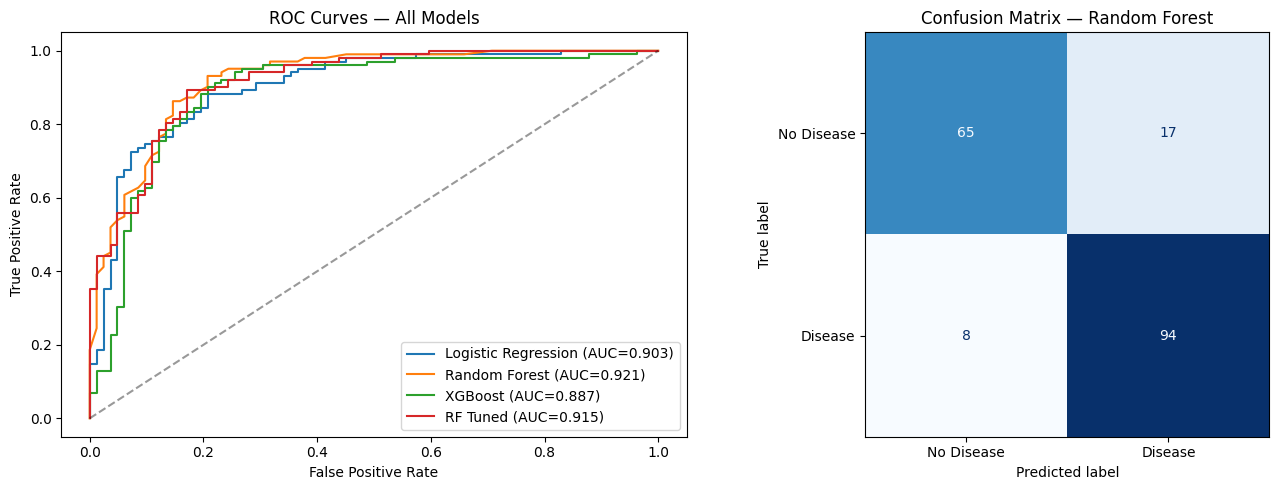


Best model: Random Forest | AUC: 0.9207


In [12]:
# ── Cell 11: Evaluation on held-out test set ─────────────────────────────────

# Evaluate all three models + the tuned RF on the test set
final_models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Random Forest':       (RandomForestClassifier(random_state=42), False),
    'XGBoost':             (xgb.XGBClassifier(n_estimators=100, random_state=42,
                                               eval_metric='logloss', verbosity=0), False),
    'RF Tuned':            (best_rf, False)
}

results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, (model, use_scaled) in final_models.items():
    X_tr = X_train_scaled if use_scaled else X_train.values
    X_te = X_test_scaled  if use_scaled else X_test.values

    model.fit(X_tr, y_train)
    y_pred  = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    auc  = roc_auc_score(y_test, y_proba)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    results[name] = {
        'auc': auc, 'fpr': fpr, 'tpr': tpr,
        'y_pred': y_pred, 'model': model
    }

    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
    print(f"\n{'='*40}")
    print(f"{name}")
    print(f"ROC-AUC: {auc:.4f}")
    print(classification_report(y_test, y_pred,
                                 target_names=['No Disease', 'Disease']))

# ROC curve
axes[0].plot([0,1],[0,1],'k--', alpha=0.4)
axes[0].set_title('ROC Curves — All Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(loc='lower right')

# Confusion matrix for best model (RF Tuned)
best_name = max(results, key=lambda k: results[k]['auc'])
ConfusionMatrixDisplay(
    confusion_matrix(y_test, results[best_name]['y_pred']),
    display_labels=['No Disease', 'Disease']
).plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Confusion Matrix — {best_name}')

plt.tight_layout()
plt.savefig('evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nBest model: {best_name} | AUC: {results[best_name]['auc']:.4f}")

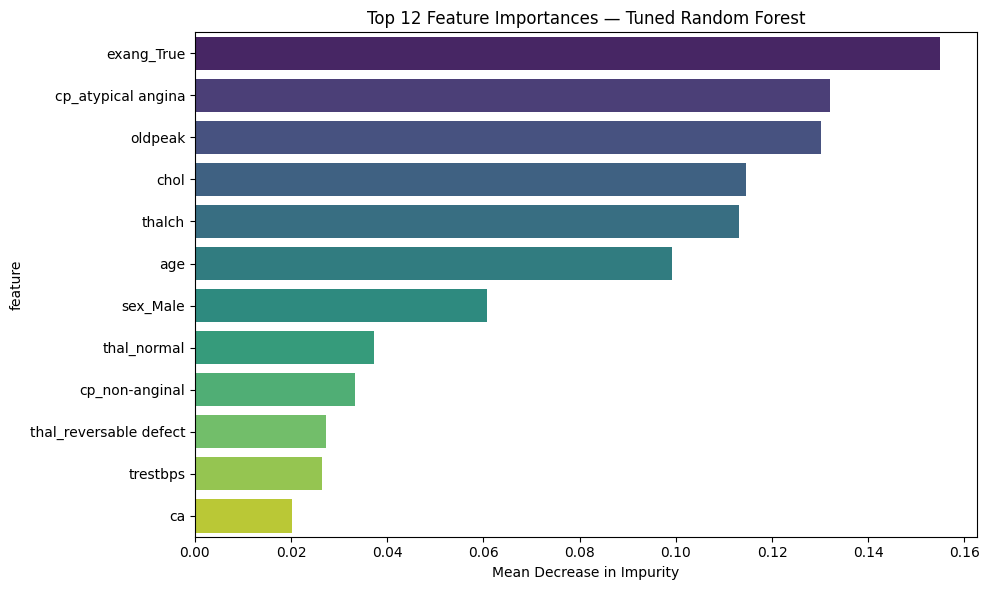


Top 12 features:
               feature  importance
            exang_True    0.154881
    cp_atypical angina    0.132039
               oldpeak    0.130117
                  chol    0.114487
                thalch    0.113128
                   age    0.099142
              sex_Male    0.060678
           thal_normal    0.037192
        cp_non-anginal    0.033389
thal_reversable defect    0.027173
              trestbps    0.026487
                    ca    0.020244


In [13]:
# ── Cell 12: Feature importance ──────────────────────────────────────────────

# Extract feature importances from the tuned Random Forest
importances = best_rf.feature_importances_
feature_names = X.columns.tolist()

feat_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feat_df, x='importance', y='feature', palette='viridis', ax=ax)
ax.set_title('Top 12 Feature Importances — Tuned Random Forest')
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 12 features:")
print(feat_df.to_string(index=False))

# WHY this matters: Feature importance tells us which clinical measurements
# drive the prediction. If thalch and oldpeak dominate, that confirms the
# clinical literature — reduced exercise capacity and ST depression are
# the strongest markers of ischemic heart disease.

## Phase 6 — MLflow Experiment Tracking

We log all four models to MLflow, pointed at DagsHub as the remote tracking server.
This makes every experiment reproducible and queryable — a core MLOps practice.

In [14]:
# ── Cell 13a: Install MLflow ──────────────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "mlflow", "dagshub", "--quiet"], check=True)
print("MLflow and DagsHub installed successfully.")

# WHY subprocess instead of !pip: Both work on Kaggle, but subprocess
# is cleaner in production-style notebooks — it captures output and
# raises an error if installation fails, rather than silently continuing.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.0 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires dacite<2,>=1.9, but you have dacite 1.6.0 which is incompatible.


MLflow and DagsHub installed successfully.


In [15]:
# ── Cell 13: MLflow experiment tracking setup ─────────────────────────────────
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import os
from kaggle_secrets import UserSecretsClient

# Securely retrieve token from Kaggle Secrets — never hardcode credentials
secrets = UserSecretsClient()
dagshub_token = secrets.get_secret("DAGSHUB_TOKEN")

DAGSHUB_USERNAME = "muhammed-keita-ml"
DAGSHUB_REPO     = "heart-disease-pipeline"

# Set credentials as environment variables for MLflow to pick up
os.environ["MLFLOW_TRACKING_USERNAME"] = DAGSHUB_USERNAME
os.environ["MLFLOW_TRACKING_PASSWORD"] = dagshub_token

# Point MLflow at DagsHub remote tracking server
mlflow.set_tracking_uri(
    f"https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow"
)

mlflow.set_experiment("heart-disease-project")

print("MLflow tracking URI set successfully.")
print(f"Tracking server: https://dagshub.com/{DAGSHUB_USERNAME}/{DAGSHUB_REPO}.mlflow")
print("Experiment: heart-disease-project")

# WHY Kaggle Secrets: Tokens stored as secrets are injected at runtime
# and never appear in your notebook code. This means your notebook is
# safe to share publicly on Kaggle without exposing credentials.

MLflow tracking URI set successfully.
Tracking server: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow
Experiment: heart-disease-project


In [16]:
# ── Cell 14: Log all models to MLflow ────────────────────────────────────────

# We log each model as a separate MLflow run.
# Each run captures: parameters, metrics, and the model artifact.
# This makes every experiment reproducible and comparable in the DagsHub UI.

log_models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=42),
        X_train_scaled, X_test_scaled,
        {'model': 'logistic_regression', 'max_iter': 1000, 'random_state': 42}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        X_train.values, X_test.values,
        {'model': 'random_forest', 'n_estimators': 100, 'random_state': 42}
    ),
    'XGBoost': (
        xgb.XGBClassifier(n_estimators=100, random_state=42,
                          eval_metric='logloss', verbosity=0),
        X_train.values, X_test.values,
        {'model': 'xgboost', 'n_estimators': 100, 'random_state': 42}
    ),
    'RF Tuned': (
        RandomForestClassifier(**grid_search.best_params_, random_state=42),
        X_train.values, X_test.values,
        {**{'model': 'random_forest_tuned', 'random_state': 42},
         **grid_search.best_params_}
    ),
}

for name, (model, X_tr, X_te, params) in log_models.items():
    with mlflow.start_run(run_name=name):

        # Train
        model.fit(X_tr, y_train)
        y_pred  = model.predict(X_te)
        y_proba = model.predict_proba(X_te)[:, 1]

        # Compute metrics
        auc      = roc_auc_score(y_test, y_proba)
        report   = classification_report(y_test, y_pred, output_dict=True)
        accuracy = report['accuracy']
        precision = report['1']['precision']
        recall    = report['1']['recall']
        f1        = report['1']['f1-score']

        # Log parameters
        # WHY: Parameters tell you exactly how the model was configured.
        # Without logging params, you can't reproduce a run later.
        mlflow.log_params(params)

        # Log metrics
        # WHY: Metrics let you compare runs side by side in the DagsHub UI.
        mlflow.log_metric("roc_auc",  auc)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall",   recall)
        mlflow.log_metric("f1_score", f1)

        # Log model artifact
        # WHY: Saving the model artifact means you can load and serve
        # this exact trained model later without retraining.
        if 'xgboost' in name.lower() or name == 'XGBoost':
            mlflow.xgboost.log_model(model, artifact_path="model")
        else:
            mlflow.sklearn.log_model(model, artifact_path="model")

        print(f"Logged: {name} | AUC={auc:.4f} | Recall={recall:.4f} | F1={f1:.4f}")

print("\nAll runs logged to DagsHub successfully.")
print(f"View at: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow")

2026/03/27 22:26:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/27 22:26:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged: Logistic Regression | AUC=0.9032 | Recall=0.8824 | F1=0.8612
🏃 View run Logistic Regression at: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow/#/experiments/1/runs/7a7549347dd5433198792a9976808dc0
🧪 View experiment at: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow/#/experiments/1


2026/03/27 22:26:24 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/27 22:26:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged: Random Forest | AUC=0.9207 | Recall=0.9216 | F1=0.8826
🏃 View run Random Forest at: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow/#/experiments/1/runs/d912adfac02040c284715b7154766255
🧪 View experiment at: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow/#/experiments/1


2026/03/27 22:26:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Logged: XGBoost | AUC=0.8870 | Recall=0.9118 | F1=0.8732
🏃 View run XGBoost at: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow/#/experiments/1/runs/c2dd741d2cba4c8893b406976db1cefc
🧪 View experiment at: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow/#/experiments/1


2026/03/27 22:27:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/27 22:27:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Logged: RF Tuned | AUC=0.9146 | Recall=0.9118 | F1=0.8651
🏃 View run RF Tuned at: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow/#/experiments/1/runs/20fc390c04054951a91a653db175f833
🧪 View experiment at: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow/#/experiments/1

All runs logged to DagsHub successfully.
View at: https://dagshub.com/muhammed-keita-ml/heart-disease-pipeline.mlflow


In [21]:
# ── Cell 17: Retrain best model and save artifacts ───────────────────────────
import joblib
import json
import os

# Retrain Random Forest here explicitly so this cell is self-contained
# WHY retrain: best_model was previously defined in the Gradio cell which
# we removed. Retraining takes only seconds and makes this cell independent.
best_model = RandomForestClassifier(random_state=42)
best_model.fit(X_train.values, y_train)

# Save model
joblib.dump(best_model, '/kaggle/working/heart_disease_model.pkl')

# Save scaler
joblib.dump(scaler, '/kaggle/working/scaler.pkl')

# Save feature names in correct column order
feature_names = X.columns.tolist()
with open('/kaggle/working/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Files saved to /kaggle/working:")
for f in os.listdir('/kaggle/working'):
    if not f.startswith('.') and not os.path.isdir(f'/kaggle/working/{f}'):
        size = os.path.getsize(f'/kaggle/working/{f}')
        print(f"  {f} — {size/1024:.1f} KB")

Files saved to /kaggle/working:
  feature_importance.png — 54.1 KB
  eda_correlation.png — 208.1 KB
  heart_disease_model.pkl — 2261.3 KB
  scaler.pkl — 1.5 KB
  feature_names.json — 0.3 KB
  evaluation.png — 99.7 KB
  eda_chestpain_oldpeak.png — 75.7 KB
  eda_distributions.png — 79.3 KB
